## 1. Imports & Configuration

In [ ]:
import re
import warnings
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import (
    r2_score, mean_absolute_error,
    mean_squared_error, mean_absolute_percentage_error
)
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBRegressor

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

# ── Reproducibility ──────────────────────────────────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ── Config ───────────────────────────────────────────────────────────────────
CENTER_ID      = 13          # fulfillment center to model
TRAIN_WEEK_CUT = 110         # weeks <= this go to train, rest to test
DATA_PATH      = 'train_merged.csv'
ENCODER_PATH   = 'encoder.pkl'
MODEL_PATH     = 'xgb_food_demand_center13.pkl'

print("✅ Libraries loaded successfully")
print(f"   Target center : {CENTER_ID}")
print(f"   Train/test cut: week {TRAIN_WEEK_CUT}")


✅ Libraries loaded successfully
   Target center : 13
   Train/test cut: week 110


## 2. Data Loading & Basic Quality Check

In [ ]:
df = pd.read_csv('train_merged.csv')

print(f"Shape          : {df.shape}")
print(f"Columns        : {list(df.columns)}")
print(f"\nDate range (week): {df['week'].min()} → {df['week'].max()}")
print(f"Unique centers : {df['center_id'].nunique()}")
print(f"Unique meals   : {df['meal_id'].nunique()}")


Shape          : (456548, 15)
Columns        : ['id', 'week', 'center_id', 'meal_id', 'checkout_price', 'base_price', 'emailer_for_promotion', 'homepage_featured', 'num_orders', 'city_code', 'region_code', 'center_type', 'op_area', 'category', 'cuisine']

Date range (week): 1 → 145
Unique centers : 77
Unique meals   : 51


In [ ]:
# ── Quality Checks ───────────────────────────────────────────────────────────
print("=" * 45)
print(f"Duplicate rows : {df.duplicated().sum()}")
print(f"\nNull values:")
print(df.isnull().sum())
print("=" * 45)

df.head()


Duplicate rows : 0

Null values:
id                       0
week                     0
center_id                0
meal_id                  0
checkout_price           0
base_price               0
emailer_for_promotion    0
homepage_featured        0
num_orders               0
city_code                0
region_code              0
center_type              0
op_area                  0
category                 0
cuisine                  0
dtype: int64


,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,city_code,region_code,center_type,op_area,category,cuisine
0,1379560,1,55,1885,136.83,152.29,0,0,177,647,56,TYPE_C,2.00,Beverages,Thai
1,1466964,1,55,1993,136.83,135.83,0,0,270,647,56,TYPE_C,2.00,Beverages,Thai
2,1346989,1,55,2539,134.86,135.86,0,0,189,647,56,TYPE_C,2.00,Beverages,Thai
3,1338232,1,55,2139,339.50,437.53,0,0,54,647,56,TYPE_C,2.00,Beverages,Indian
4,1448490,1,55,2631,243.50,242.50,0,0,40,647,56,TYPE_C,2.00,Beverages,Indian


In [ ]:
df.describe()


,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,city_code,region_code,op_area
count,456548.00,456548.00,456548.00,456548.00,456548.00,456548.00,456548.00,456548.00,456548.00,456548.00,456548.00,456548.00
mean,1250096.31,74.77,82.11,2024.34,332.24,354.16,0.08,0.11,261.87,601.55,56.61,4.08
std,144354.82,41.52,45.98,547.42,152.94,160.72,0.27,0.31,395.92,66.20,17.64,1.09
min,1000000.00,1.00,10.00,1062.00,2.97,55.35,0.00,0.00,13.00,456.00,23.00,0.90
25%,1124998.75,39.00,43.00,1558.00,228.95,243.50,0.00,0.00,54.00,553.00,34.00,3.60
50%,1250183.50,76.00,76.00,1993.00,296.82,310.46,0.00,0.00,136.00,596.00,56.00,4.00
75%,1375140.25,111.00,110.00,2539.00,445.23,458.87,0.00,0.00,324.00,651.00,77.00,4.50
max,1499999.00,145.00,186.00,2956.00,866.27,866.27,1.00,1.00,24299.00,713.00,93.00,7.00


## 3. Exploratory Data Analysis (EDA)

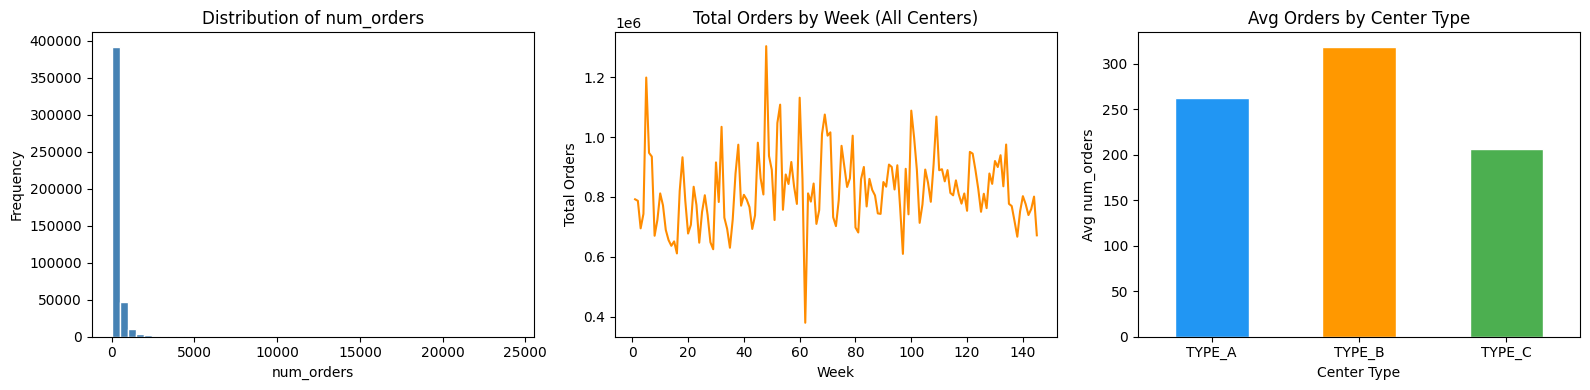

💡 Insight: Check for seasonal/weekly trends in the middle chart above.


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Target distribution
axes[0].hist(df['num_orders'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of num_orders')
axes[0].set_xlabel('num_orders')
axes[0].set_ylabel('Frequency')

# Orders over time (global trend)
weekly = df.groupby('week')['num_orders'].sum().reset_index()
axes[1].plot(weekly['week'], weekly['num_orders'], color='darkorange', linewidth=1.5)
axes[1].set_title('Total Orders by Week (All Centers)')
axes[1].set_xlabel('Week')
axes[1].set_ylabel('Total Orders')

# Orders by center type
df.groupby('center_type')['num_orders'].mean().plot(
    kind='bar', ax=axes[2], color=['#2196F3','#FF9800','#4CAF50'], edgecolor='white'
)
axes[2].set_title('Avg Orders by Center Type')
axes[2].set_xlabel('Center Type')
axes[2].set_ylabel('Avg num_orders')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=120, bbox_inches='tight')
plt.show()
print("💡 Insight: Check for seasonal/weekly trends in the middle chart above.")


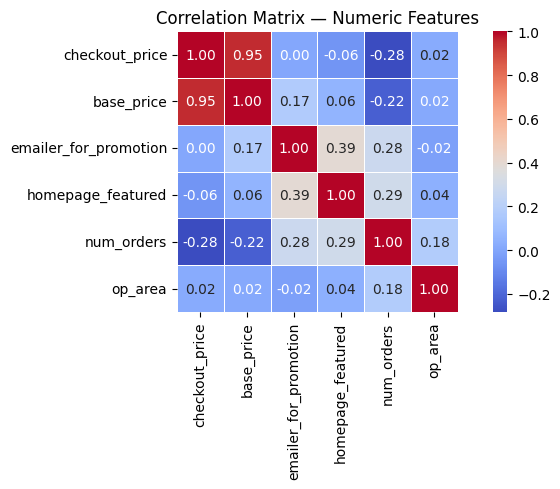

In [ ]:
# ── Correlation heatmap for numeric cols ─────────────────────────────────────
num_cols = ['checkout_price', 'base_price', 'emailer_for_promotion',
            'homepage_featured', 'num_orders', 'op_area']
corr = df[num_cols].corr()

plt.figure(figsize=(8, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Correlation Matrix — Numeric Features')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()


## 4. Feature Engineering

**New features created:**
| Feature | Logic | Rationale |
|---|---|---|
| `discount` | `base_price - checkout_price` | Absolute discount amount |
| `discount_per` | `(discount / base_price) * 100` | Relative discount % |
| `discount_bin` | Binned `discount_per` | Captures non-linear discount effect |
| `price_band` | Binned `checkout_price` | Price sensitivity segmentation |


In [ ]:
# ── Discount features ────────────────────────────────────────────────────────
df['discount'] = (df['base_price'] - df['checkout_price']).round(2)

df['discount_per'] = (
    ((df['base_price'] - df['checkout_price']) / df['base_price']) * 100
).round(2)

# Clip negative discounts to 0 (data quality fix)
negative_disc_count = (df['discount_per'] < 0).sum()
df['discount_per'] = df['discount_per'].clip(lower=0)
print(f"⚠️  Clipped {negative_disc_count} rows with negative discount_per to 0")

# ── Discount bins ─────────────────────────────────────────────────────────────
disc_bins   = [-0.01, 0, 5, 10, 20, 30, 40, 50, 100]
disc_labels = ['0', '0-5', '5-10', '10-20', '20-30', '30-40', '40-50', '50-100']
df['discount_bin'] = pd.cut(df['discount_per'], bins=disc_bins,
                            labels=disc_labels, include_lowest=True)

# ── Price band ────────────────────────────────────────────────────────────────
price_bins   = [0, 100, 150, 200, 250, 300, 400, 600, np.inf]
price_labels = ['<=100', '101-150', '151-200', '201-250',
                '251-300', '301-400', '401-600', '600+']
df['price_band'] = pd.cut(df['checkout_price'], bins=price_bins,
                          labels=price_labels, include_lowest=True)

print("\n✅ Feature engineering complete")
print(df[['base_price', 'checkout_price', 'discount', 'discount_per',
          'discount_bin', 'price_band']].head())


⚠️  Clipped 116100 rows with negative discount_per to 0

✅ Feature engineering complete
   base_price  checkout_price  discount  discount_per discount_bin price_band
0      152.29          136.83     15.46         10.15        10-20    101-150
1      135.83          136.83     -1.00          0.00            0    101-150
2      135.86          134.86      1.00          0.74          0-5    101-150
3      437.53          339.50     98.03         22.41        20-30    301-400
4      242.50          243.50     -1.00          0.00            0    201-250


## 5. Categorical Encoding (OneHotEncoder)

In [ ]:
cat_col = ['center_type', 'category', 'cuisine', 'discount_bin', 'price_band']

encoder = OneHotEncoder(
    sparse_output=False,   # return dense array
    handle_unknown='ignore' # silently ignore unseen categories at inference
)

encoder.fit(df[cat_col])
encoded     = encoder.transform(df[cat_col])
encoded_df  = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(cat_col))

# Merge back
df = pd.concat([df.drop(columns=cat_col).reset_index(drop=True), encoded_df], axis=1)

# Persist encoder for inference/deployment
joblib.dump(encoder, ENCODER_PATH)

print(f"✅ Encoder saved → {ENCODER_PATH}")
print(f"   Encoded features added : {encoded_df.shape[1]}")
print(f"   Final dataframe shape  : {df.shape}")


✅ Encoder saved → encoder.pkl
   Encoded features added : 37
   Final dataframe shape  : (456548, 51)


## 6. Filter Data — Center ID 13

In [ ]:
center_df = df[df['center_id'] == CENTER_ID].copy()
center_df = center_df.sort_values(['meal_id', 'week']).reset_index(drop=True)

print(f"Rows for center {CENTER_ID}  : {len(center_df)}")
print(f"Unique meals in center       : {center_df['meal_id'].nunique()}")
print(f"Week range                  : {center_df['week'].min()} → {center_df['week'].max()}")


Rows for center 13  : 7046
Unique meals in center       : 51
Week range                  : 1 → 145


In [ ]:
# ── Select relevant columns ───────────────────────────────────────────────────
base_cols = [
    'week', 'meal_id', 'emailer_for_promotion', 'homepage_featured',
    'num_orders', 'op_area', 'discount_per'
]

ohe_cols = [c for c in center_df.columns if c.startswith(('center_type_',
            'category_', 'cuisine_', 'discount_bin_', 'price_band_'))]

# Sanitize column names for XGBoost (no special chars)
center_df.columns = (
    center_df.columns.astype(str)
    .str.replace(r'[^a-zA-Z0-9_]', '', regex=True)
)

# Re-identify ohe_cols after sanitization
ohe_cols_clean = [c for c in center_df.columns if c.startswith(('center_type_',
                  'category_', 'cuisine_', 'discount_bin_', 'price_band_'))]

selected_cols = base_cols + ohe_cols_clean
# Sanitize base_col names too (price_band has <=)
selected_cols_clean = [
    re.sub(r'[^a-zA-Z0-9_]', '', c) for c in selected_cols
]
center_df = center_df[[c for c in selected_cols_clean if c in center_df.columns]]

print(f"✅ Final columns selected : {center_df.shape[1]}")


✅ Final columns selected : 44
